In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

from sklearn.ensemble import BaggingClassifier 

In [2]:
url =  'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url, names = names)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
# Feature and Target 
X =  data.iloc[:, :-1]
y =  data.iloc[:, -1] 

## train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state= 42)

In [4]:
imputer = SimpleImputer(strategy = 'median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.fit_transform(X_test)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train_imputed)
X_test_sc = sc.fit_transform(X_test_imputed)



In [5]:
kf = KFold(n_splits = 10, shuffle= True, random_state = 42)
dt_clf = LogisticRegression()
num_tree = 100


In [6]:
bagging_model = BaggingClassifier(estimator=dt_clf,n_estimators = 100, random_state = 42, 
                                  oob_score = True)
res_bag = cross_val_score(bagging_model,X_train_sc,y_train, cv=kf)

print (f'Cross_val score , {res_bag}')
print (f'Cross_val score , {res_bag.mean()}')


Cross_val score , [0.83870968 0.74193548 0.79032258 0.72580645 0.75409836 0.68852459
 0.7704918  0.7704918  0.80327869 0.75409836]
Cross_val score , 0.7637757800105763


In [7]:
bagging_model.fit(X_train_sc, y_train)

BaggingClassifier(estimator=LogisticRegression(), n_estimators=100,
                  oob_score=True, random_state=42)

Results for Bagging Classifier
---------------------------------------------------------------------------
Training Accuracy - 0.7703583061889251
Test Accuracy - 0.7857142857142857
Classification Report - Test Set
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        99
           1       0.73      0.64      0.68        55

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.76       154
weighted avg       0.78      0.79      0.78       154

Confusion Matrix


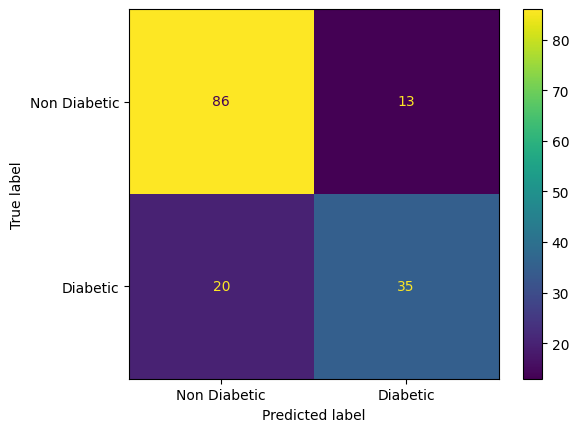

In [8]:
print('Results for Bagging Classifier')
print('-'* 75)
y_train_pred =  bagging_model.predict(X_train_sc)
y_test_pred =  bagging_model.predict(X_test_sc)
print(f'Training Accuracy - {accuracy_score(y_train,y_train_pred)}')
print(f'Test Accuracy - {accuracy_score(y_test,y_test_pred)}')

print('Classification Report - Test Set')
print(classification_report(y_test,y_test_pred))

print('Confusion Matrix')
cm = confusion_matrix(y_test,y_test_pred)
disp =  ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Non Diabetic', 'Diabetic'])
disp.plot()
plt.show()

In [9]:
oob_error = 1 - bagging_model.oob_score_
oob_error

0.23289902280130292

In [10]:
from sklearn.ensemble import AdaBoostClassifier


In [11]:
adaboost = AdaBoostClassifier(n_estimators=200,random_state=42)
res_bag = cross_val_score(adaboost,X_train_sc,y_train, cv=kf)

print (f'Cross_val score , {res_bag}')
print (f'Cross_val score , {res_bag.mean()}')

Cross_val score , [0.77419355 0.75806452 0.79032258 0.70967742 0.73770492 0.75409836
 0.72131148 0.73770492 0.7704918  0.75409836]
Cross_val score , 0.7507667900581703


In [12]:
adaboost = AdaBoostClassifier(n_estimators=100,random_state=25)
res_bag

array([0.77419355, 0.75806452, 0.79032258, 0.70967742, 0.73770492,
       0.75409836, 0.72131148, 0.73770492, 0.7704918 , 0.75409836])

Results for Bagging Classifier
---------------------------------------------------------------------------
Training Accuracy - 0.7703583061889251
Test Accuracy - 0.7857142857142857
Classification Report - Test Set
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        99
           1       0.73      0.64      0.68        55

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.76       154
weighted avg       0.78      0.79      0.78       154

Confusion Matrix


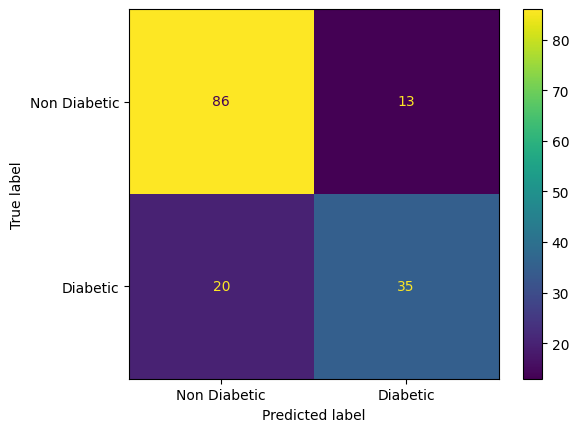

In [13]:
print('Results for Bagging Classifier')
print('-'* 75)
y_train_pred =  bagging_model.predict(X_train_sc)
y_test_pred =  bagging_model.predict(X_test_sc)
print(f'Training Accuracy - {accuracy_score(y_train,y_train_pred)}')
print(f'Test Accuracy - {accuracy_score(y_test,y_test_pred)}')

print('Classification Report - Test Set')
print(classification_report(y_test,y_test_pred))

print('Confusion Matrix')
cm = confusion_matrix(y_test,y_test_pred)
disp =  ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Non Diabetic', 'Diabetic'])
disp.plot()
plt.show()

In [15]:
!pip install vecstack

In [ ]:
# import libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier # base model 1
from sklearn.ensemble import RandomForestClassifier # base model 2
from xgboost import XGBClassifier # base model 3
from sklearn.tree import DecisionTreeClassifier # base model 4


from sklearn.linear_model import LogisticRegression # to be used as meta model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler

from vecstack import stacking
